In [3]:
#Fix relative paths
from pathlib import Path
import sys

p = Path.cwd().resolve()
repo_root = next(parent for parent in [p, *p.parents] if (parent / "src").exists())
sys.path.insert(0, str(repo_root / "src"))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from torch_dataset import ImagePathDataset
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import torch.nn.functional as F

from dataset import load_split
from efficientnet_helpers import (
    EffNetConfig,
    set_seed,
    set_torch_perf_flags,
    make_transforms,
    build_efficientnet_b0,
    make_optimizer,
    make_loaders_for_fold,
    train_one_epoch,
    predict_epoch,
    compute_metrics,
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)
set_torch_perf_flags()

DEVICE: cuda


In [5]:
"""DATA-SPLITTING"""
train_paths, test_paths, y_train, y_test, meta = load_split(repo_root / "splits")

train_paths = np.asarray(train_paths)
test_paths  = np.asarray(test_paths)
y_train = np.asarray(y_train, dtype=np.int64)
y_test  = np.asarray(y_test, dtype=np.int64)

num_classes = int(len(np.unique(y_train)))
print("train:", len(train_paths), "test:", len(test_paths), "classes:", num_classes)

CFG = EffNetConfig(
    img_size=224,
    batch_size=64,
    num_workers=4,
    unfreeze_last_n=2,
    lr_head=3e-4,
    lr_ft=1e-4,
    weight_decay=1e-4,
    use_weighted_sampler=True,
    seed=42,
)

EPOCHS = 20
PATIENCE = 4  # early stopping per fold
FOLDS = 5
set_seed(CFG.seed)

train: 6073 test: 2604 classes: 101


In [6]:
"""TRANSFORM"""
train_tf, eval_tf = make_transforms(img_size=CFG.img_size)

In [7]:
"""CROSS-VALIDATION"""
from sklearn.model_selection import StratifiedKFold
from copy import deepcopy

skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=CFG.seed)

fold_results = []

for fold_id, (tr_idx, va_idx) in enumerate(skf.split(train_paths, y_train), start=1):
    print(f"\n===== Fold {fold_id}/{FOLDS} =====")

    # Build model fresh for this fold
    model = build_efficientnet_b0(
        num_classes=num_classes,
        unfreeze_last_n=CFG.unfreeze_last_n,
        device=DEVICE,
    )

    optimizer = make_optimizer(
        model,
        unfreeze_last_n=CFG.unfreeze_last_n,
        lr_head=CFG.lr_head,
        lr_ft=CFG.lr_ft,
        weight_decay=CFG.weight_decay,
    )

    scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))

    # Loaders for this fold
    train_loader, val_loader = make_loaders_for_fold(
        train_paths=train_paths,
        y_train=y_train,
        train_idx=tr_idx,
        val_idx=va_idx,
        train_tf=train_tf,
        eval_tf=eval_tf,
        batch_size=CFG.batch_size,
        num_workers=CFG.num_workers,
        use_weighted_sampler=CFG.use_weighted_sampler,
        num_classes=num_classes,
    )

    best_val_acc = -1.0
    best_state = None
    bad_epochs = 0

    for epoch in range(1, EPOCHS + 1):
        tr_loss = train_one_epoch(model, train_loader, optimizer, scaler, device=DEVICE)

        y_va_true, y_va_pred = predict_epoch(model, val_loader, device=DEVICE)
        m = compute_metrics(y_va_true, y_va_pred)

        print(f"Fold {fold_id} | Epoch {epoch:02d} | "
              f"train_loss {tr_loss:.4f} | val_acc {m['accuracy']:.4f} | val_f1 {m['micro_f1']:.4f}")

        if m["accuracy"] > best_val_acc:
            best_val_acc = m["accuracy"]
            best_state = deepcopy({k: v.detach().cpu() for k, v in model.state_dict().items()})
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= PATIENCE:
                print("Early stopping.")
                break

    # Evaluate best checkpoint on val
    model.load_state_dict(best_state)
    y_va_true, y_va_pred = predict_epoch(model, val_loader, device=DEVICE)
    best_m = compute_metrics(y_va_true, y_va_pred)
    best_m["fold"] = fold_id

    fold_results.append(best_m)
    print(f"Fold {fold_id} BEST | val_acc {best_m['accuracy']:.4f} | val_f1 {best_m['micro_f1']:.4f}")


===== Fold 1/5 =====


C:\Users\Kwame Boateng\AppData\Local\Temp\ipykernel_13928\1986085794.py:27: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))
C:\Users\Kwame Boateng\Documents\GitHub\AI_In_Medicine_Project_1\src\efficientnet_helpers.py:288: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(str(device).startswith("cuda"))):


Fold 1 | Epoch 01 | train_loss 2.8760 | val_acc 0.8535 | val_f1 0.8535


C:\Users\Kwame Boateng\Documents\GitHub\AI_In_Medicine_Project_1\src\efficientnet_helpers.py:288: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(str(device).startswith("cuda"))):


Fold 1 | Epoch 02 | train_loss 1.2069 | val_acc 0.9078 | val_f1 0.9078


...

Fold 5 | Epoch 14 | train_loss 0.8763 | val_acc 0.9465 | val_f1 0.9465


C:\Users\Kwame Boateng\Documents\GitHub\AI_In_Medicine_Project_1\src\efficientnet_helpers.py:288: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(str(device).startswith("cuda"))):


Fold 5 | Epoch 15 | train_loss 0.8737 | val_acc 0.9440 | val_f1 0.9440


C:\Users\Kwame Boateng\Documents\GitHub\AI_In_Medicine_Project_1\src\efficientnet_helpers.py:288: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(str(device).startswith("cuda"))):


Fold 5 | Epoch 16 | train_loss 0.8687 | val_acc 0.9432 | val_f1 0.9432
Early stopping.
Fold 5 BEST | val_acc 0.9506 | val_f1 0.9506


C:\Users\Kwame Boateng\AppData\Local\Temp\ipykernel_13928\231928545.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  final_scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))
C:\Users\Kwame Boateng\Documents\GitHub\AI_In_Medicine_Project_1\src\efficientnet_helpers.py:288: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(str(device).startswith("cuda"))):


FINAL | Epoch 01 | train_loss 2.5799
FINAL | Epoch 02 | train_loss 1.1613
FINAL | Epoch 03 | train_loss 1.0731
FINAL | Epoch 04 | train_loss 1.0066
FINAL | Epoch 05 | train_loss 0.9838
FINAL | Epoch 06 | train_loss 0.9565
FINAL | Epoch 07 | train_loss 0.9383
FINAL | Epoch 08 | train_loss 0.9230
FINAL | Epoch 09 | train_loss 0.9113
FINAL | Epoch 10 | train_loss 0.8999
FINAL | Epoch 11 | train_loss 0.8933
FINAL | Epoch 12 | train_loss 0.8838
FINAL | Epoch 13 | train_loss 0.8815
FINAL | Epoch 14 | train_loss 0.8754
FINAL | Epoch 15 | train_loss 0.8724
FINAL | Epoch 16 | train_loss 0.8711
FINAL | Epoch 17 | train_loss 0.8649
FINAL | Epoch 18 | train_loss 0.8599
FINAL | Epoch 19 | train_loss 0.8588
FINAL | Epoch 20 | train_loss 0.8537


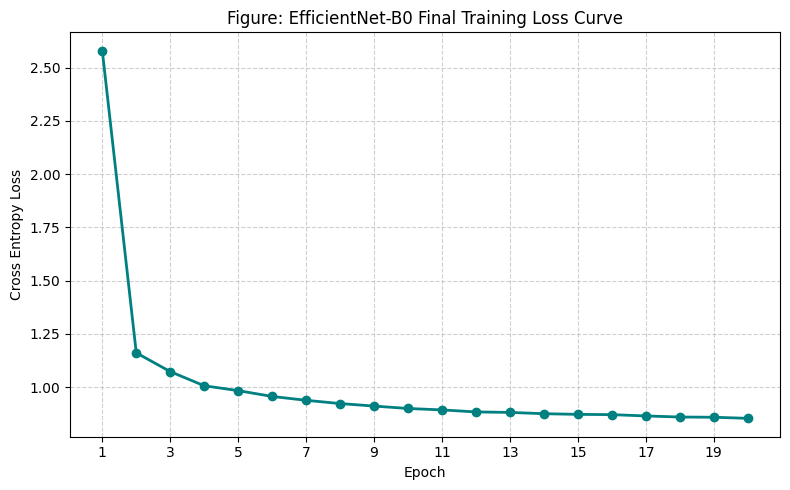


TEST | acc: 0.9504608294930875 | micro-F1: 0.9504608294930875


In [ ]:
# Build final model
final_model = build_efficientnet_b0(
    num_classes=num_classes,
    unfreeze_last_n=CFG.unfreeze_last_n,
    device=DEVICE,
)
final_opt = make_optimizer(
    final_model,
    unfreeze_last_n=CFG.unfreeze_last_n,
    lr_head=CFG.lr_head,
    lr_ft=CFG.lr_ft,
    weight_decay=CFG.weight_decay,
)
final_scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))

# Train loader on all train
all_idx = np.arange(len(train_paths))
train_loader_all, _ = make_loaders_for_fold(
    train_paths=train_paths,
    y_train=y_train,
    train_idx=all_idx,
    val_idx=all_idx[:0],          # unused empty val
    train_tf=train_tf,
    eval_tf=eval_tf,
    batch_size=CFG.batch_size,
    num_workers=CFG.num_workers,
    use_weighted_sampler=CFG.use_weighted_sampler,
    num_classes=num_classes,
)

# Build a proper test loader
test_ds = ImagePathDataset([str(p) for p in test_paths], y_test, transform=eval_tf)
test_loader = DataLoader(
    test_ds,
    batch_size=CFG.batch_size,
    shuffle=False,
    num_workers=CFG.num_workers,
    pin_memory=True,
    persistent_workers=(CFG.num_workers > 0),
)


# Train
# Initialize lists to store history
final_train_loss_history = []
epochs_list = []

for epoch in range(1, EPOCHS + 1):
    tr_loss = train_one_epoch(final_model, train_loader_all, final_opt, final_scaler, device=DEVICE)
    print(f"FINAL | Epoch {epoch:02d} | train_loss {tr_loss:.4f}")
    
    #Save the loss for this epoch
    final_train_loss_history.append(tr_loss)
    epochs_list.append(epoch)

plt.figure(figsize=(8, 5))
plt.plot(epochs_list, final_train_loss_history, marker='o', color='teal', linewidth=2)

plt.title("Figure: EfficientNet-B0 Final Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.xticks(epochs_list[::2])
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Save
plt.savefig("efficientnet_final_loss.png", dpi=300)
plt.show()
# Test
y_te_true, y_te_pred = predict_epoch(final_model, test_loader, device=DEVICE)
test_m = compute_metrics(y_te_true, y_te_pred)
print("\nTEST | acc:", test_m["accuracy"], "| micro-F1:", test_m["micro_f1"])

--- EFFICIENTNET-B0 OVERALL METRICS ---
              precision    recall  f1-score   support

           0      0.915     0.985     0.949       131
           1      0.983     0.908     0.944       131
           2      0.984     1.000     0.992        60
           3      1.000     1.000     1.000       239
           4      1.000     1.000     1.000        16
           5      1.000     0.975     0.987       240
           6      1.000     0.615     0.762        13
           7      0.818     0.692     0.750        13
           8      1.000     1.000     1.000        14
           9      0.929     0.812     0.867        16
          10      0.833     0.714     0.769        14
          11      1.000     1.000     1.000        10
          12      0.974     0.974     0.974        38
          13      0.963     0.897     0.929        29
          14      0.750     0.923     0.828        13
          15      1.000     1.000     1.000        26
          16      0.900     1.000     0.9

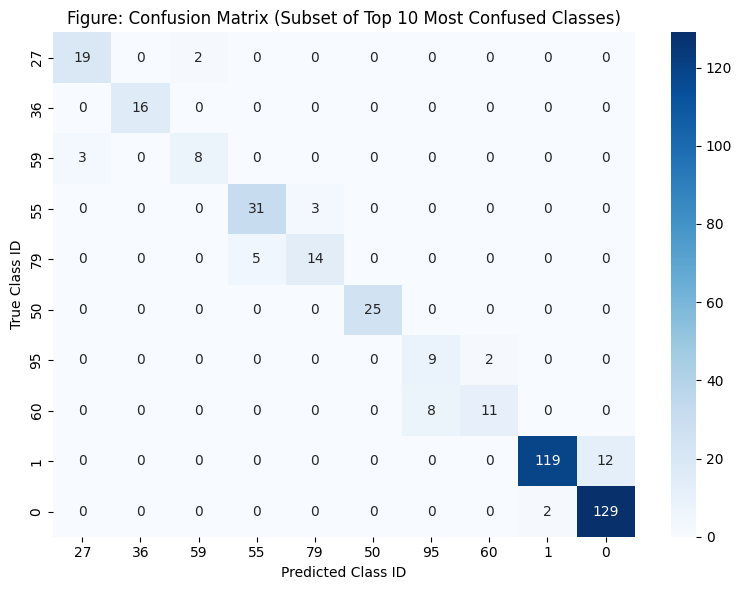

In [ ]:
final_model.eval()
all_preds = []
all_labels = []
all_probs = []

#Get Predictions and Probabilities
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE)
        logits = final_model(x)
        probs = F.softmax(logits, dim=1)
        
        all_probs.append(probs.cpu().numpy())
        all_preds.append(torch.argmax(logits, dim=1).cpu().numpy())
        all_labels.append(y.numpy())

all_probs = np.concatenate(all_probs)
all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

#Print Standard Classification Report
print("--- EFFICIENTNET-B0 OVERALL METRICS ---")
print(classification_report(all_labels, all_preds, digits=3))

#Calculate Top-5 Accuracy
top5_preds = np.argsort(all_probs, axis=1)[:, -5:] # Get indices of top 5 probs
top5_correct = 0
for i, true_label in enumerate(all_labels):
    if true_label in top5_preds[i]:
        top5_correct += 1
top5_acc = top5_correct / len(all_labels)
print(f"\nTop-1 Accuracy: {accuracy_score(all_labels, all_preds):.4f}")
print(f"Top-5 Accuracy: {top5_acc:.4f}")

# Plot a "Top 10 Most Confused" Matrix
cm = confusion_matrix(all_labels, all_preds)

# Find off-diagonal errors
np.fill_diagonal(cm, 0)
error_sums = cm.sum(axis=1) + cm.sum(axis=0)
top_error_indices = np.argsort(error_sums)[-10:] # Get top 10 worst classes

# Re-calculate true CM for just those 10 classes
cm_real = confusion_matrix(all_labels, all_preds)
cm_subset = cm_real[np.ix_(top_error_indices, top_error_indices)]

plt.figure(figsize=(8, 6))
sns.heatmap(cm_subset, annot=True, fmt='d', cmap='Blues', 
            xticklabels=top_error_indices, yticklabels=top_error_indices)
plt.title("Figure: Confusion Matrix (Subset of Top 10 Most Confused Classes)")
plt.xlabel("Predicted Class ID")
plt.ylabel("True Class ID")
plt.tight_layout()
plt.savefig("efficientnet_confusion_matrix.png", dpi=300)
plt.show()

In [ ]:
"""ABLATION 1"""
print("--- STARTING FROZEN BACKBONE ABLATION ---")
from sklearn.metrics import classification_report

#Build the model with unfreeze_last_n = 0
frozen_model = build_efficientnet_b0(
    num_classes=num_classes, 
    unfreeze_last_n=0,       #ALL CONV LAYERS FROZEN
    device=DEVICE
)

#Create optimizer and scaler (only the head is trainable)
frozen_opt = make_optimizer(frozen_model, unfreeze_last_n=0, lr_head=3e-4, lr_ft=1e-4, weight_decay=1e-4)
frozen_scaler = torch.amp.GradScaler('cuda', enabled=(DEVICE == "cuda"))

#Train for the same number of epochs
for epoch in range(1, EPOCHS + 1):
    tr_loss = train_one_epoch(frozen_model, train_loader_all, frozen_opt, frozen_scaler, device=DEVICE)
    print(f"Frozen Epoch {epoch:02d} | train_loss {tr_loss:.4f}")

#Evaluate on Test Set
y_te_true_f, y_te_pred_f = predict_epoch(frozen_model, test_loader, device=DEVICE)
print("\n--- FROZEN BACKBONE RESULTS ---")
print(classification_report(y_te_true_f, y_te_pred_f, digits=3))

--- STARTING FROZEN BACKBONE ABLATION ---


C:\Users\Kwame Boateng\Documents\GitHub\AI_In_Medicine_Project_1\src\efficientnet_helpers.py:288: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(str(device).startswith("cuda"))):


Frozen Epoch 01 | train_loss 3.7121
Frozen Epoch 02 | train_loss 2.2671
Frozen Epoch 03 | train_loss 1.5663
Frozen Epoch 04 | train_loss 1.2911
Frozen Epoch 05 | train_loss 1.1604
Frozen Epoch 06 | train_loss 1.1042
Frozen Epoch 07 | train_loss 1.0677
Frozen Epoch 08 | train_loss 1.0394
Frozen Epoch 09 | train_loss 1.0130
Frozen Epoch 10 | train_loss 1.0010
Frozen Epoch 11 | train_loss 0.9904
Frozen Epoch 12 | train_loss 0.9826
Frozen Epoch 13 | train_loss 0.9652
Frozen Epoch 14 | train_loss 0.9588
Frozen Epoch 15 | train_loss 0.9569
Frozen Epoch 16 | train_loss 0.9513
Frozen Epoch 17 | train_loss 0.9391
Frozen Epoch 18 | train_loss 0.9419
Frozen Epoch 19 | train_loss 0.9322
Frozen Epoch 20 | train_loss 0.9302

--- FROZEN BACKBONE RESULTS ---
              precision    recall  f1-score   support

           0      0.891     0.809     0.848       131
           1      0.824     0.893     0.857       131
           2      1.000     1.000     1.000        60
           3      1.000     1.

In [ ]:
"""ABLATION 2"""
print("--- STARTING RANDOM INIT ABLATION ---")

#Build the model with NO pre-trained weights
scratch_model = build_efficientnet_b0(
    num_classes=num_classes, 
    unfreeze_last_n=2, 
    weights=None,            #REMOVES IMAGENET KNOWLEDGE
    device=DEVICE
)

#Create optimizer and scaler
scratch_opt = make_optimizer(scratch_model, unfreeze_last_n=2, lr_head=3e-4, lr_ft=1e-4, weight_decay=1e-4)
scratch_scaler = torch.amp.GradScaler('cuda', enabled=(DEVICE == "cuda"))

#Train
for epoch in range(1, EPOCHS + 1):
    tr_loss = train_one_epoch(scratch_model, train_loader_all, scratch_opt, scratch_scaler, device=DEVICE)
    print(f"Scratch Epoch {epoch:02d} | train_loss {tr_loss:.4f}")

#Evaluate on Test Set
y_te_true_s, y_te_pred_s = predict_epoch(scratch_model, test_loader, device=DEVICE)
print("\n--- SCRATCH MODEL RESULTS ---")
print(classification_report(y_te_true_s, y_te_pred_s, digits=3))

--- STARTING RANDOM INIT ABLATION ---


C:\Users\Kwame Boateng\Documents\GitHub\AI_In_Medicine_Project_1\src\efficientnet_helpers.py:288: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(str(device).startswith("cuda"))):


Scratch Epoch 01 | train_loss 4.6154
Scratch Epoch 02 | train_loss 4.6151
Scratch Epoch 03 | train_loss 4.6154
Scratch Epoch 04 | train_loss 4.6154
Scratch Epoch 05 | train_loss 4.6154
Scratch Epoch 06 | train_loss 4.6152
Scratch Epoch 07 | train_loss 4.6153
Scratch Epoch 08 | train_loss 4.6154
Scratch Epoch 09 | train_loss 4.6153
Scratch Epoch 10 | train_loss 4.6152
Scratch Epoch 11 | train_loss 4.6154
Scratch Epoch 12 | train_loss 4.6154
Scratch Epoch 13 | train_loss 4.6153
Scratch Epoch 14 | train_loss 4.6155
Scratch Epoch 15 | train_loss 4.6155
Scratch Epoch 16 | train_loss 4.6151
Scratch Epoch 17 | train_loss 4.6154
Scratch Epoch 18 | train_loss 4.6154
Scratch Epoch 19 | train_loss 4.6152
Scratch Epoch 20 | train_loss 4.6154

--- SCRATCH MODEL RESULTS ---
              precision    recall  f1-score   support

           0      0.000     0.000     0.000       131
           1      0.000     0.000     0.000       131
           2      0.000     0.000     0.000        60
           3

c:\Users\Kwame Boateng\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Kwame Boateng\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Kwame Boateng\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this b